# Sistema Multi-Agente ReAct para Auditoría de Inteligencia Financiera

**Curso:** Arquitecturas de Modelos de Lenguaje (LLMs)
**Proyecto Final — Opción 2:** Sistema Operativo de Agentes Cognitivos para Inteligencia Competitiva

---

## Resumen

Este notebook implementa un sistema multi-agente que responde consultas financieras complejas
mediante tres agentes con roles diferenciados, coordinados por un grafo cíclico de control
(LangGraph):

1. **Agente Investigador** — recupera evidencia de una base de conocimiento vectorial (ChromaDB)
   y de búsqueda web (DuckDuckGo), y redacta un borrador de respuesta citando sus fuentes.
2. **Agente Auditor de Hechos** — audita el borrador contra el contexto recuperado. Si detecta
   afirmaciones sin respaldo o datos específicos no confirmados, rechaza el borrador y lo
   devuelve al Investigador con una razón concreta de rechazo.
3. **Agente Redactor** — transforma el borrador aprobado en la respuesta final.

El modelo orquestador es `Mistral-7B-Instruct-v0.3` en 4-bit, ejecutado localmente. El sistema
no realiza ajuste fino de pesos: toda la capacidad de razonamiento proviene de la orquestación
e inferencia sobre el modelo base.

El sistema se evalúa contra un baseline de **Naive RAG** (recuperación + una sola generación,
sin auditoría) sobre 50 consultas complejas, usando dos métricas calculadas por un juez externo
(`gpt-4.1-mini`, vía API de OpenAI): **Faithfulness** y **Answer Relevance**.

## Tabla de contenidos

| Sección | Contenido |
|---|---|
| 1 | Configuración del entorno |
| 2 | Carga del modelo de lenguaje |
| 3 | Base de conocimiento vectorial |
| 4 | Herramienta de búsqueda web |
| 5 | Definición de los agentes |
| 6 | Grafo de control multi-agente |
| 7 | Validación funcional del sistema |
| 8 | Sistema de referencia: Naive RAG |
| 9 | Conjunto de evaluación: 50 consultas complejas |
| 10 | Ejecución de la evaluación |
| 11 | Evaluación cuantitativa (LLM-as-a-Judge) |
| 12 | Tabla y gráfico comparativo |
| 13 | Diagrama del grafo de agentes |
| 14 | Interfaz de demostración |
| 15 | Conclusiones |


## 1. Configuración del entorno

In [1]:
!pip install -q transformers accelerate bitsandbytes langchain langchain-community langchain-openai langgraph langchain-huggingface chromadb sentence-transformers datasets ddgs gradio openai matplotlib tabulate
!pip install -q --force-reinstall --no-deps triton



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from getpass import getpass

if "OPENAI_API_KEY" not in os.environ or not os.environ["OPENAI_API_KEY"]:
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")


In [3]:
import torch
from tabulate import tabulate

info_entorno = [
    ["GPU disponible", torch.cuda.is_available()],
    ["Dispositivo", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"],
    ["VRAM total (GB)", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}" if torch.cuda.is_available() else "N/A"],
]
print(tabulate(info_entorno, headers=["Parámetro", "Valor"], tablefmt="rounded_outline"))


╭─────────────────┬─────────────╮
│ Parámetro       │ Valor       │
├─────────────────┼─────────────┤
│ GPU disponible  │ True        │
│ Dispositivo     │ NVIDIA L40S │
│ VRAM total (GB) │ 47.7        │
╰─────────────────┴─────────────╯


## 2. Carga del modelo de lenguaje

Se utiliza `Mistral-7B-Instruct-v0.3` cuantizado en 4 bits (NF4, doble cuantización). Este mismo
modelo actúa como los tres agentes del sistema: lo que cambia entre roles es exclusivamente el
prompt de sistema en cada llamada.

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

print(tabulate(
    [["Modelo", MODEL_ID], ["Memoria GPU asignada (GB)", f"{torch.cuda.memory_allocated()/1e9:.2f}"]],
    headers=["Parámetro", "Valor"], tablefmt="rounded_outline",
))


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

╭───────────────────────────┬────────────────────────────────────╮
│ Parámetro                 │ Valor                              │
├───────────────────────────┼────────────────────────────────────┤
│ Modelo                    │ mistralai/Mistral-7B-Instruct-v0.3 │
│ Memoria GPU asignada (GB) │ 4.14                               │
╰───────────────────────────┴────────────────────────────────────╯


In [5]:
def generar(system_prompt: str, user_prompt: str, max_new_tokens: int = 512, temperature: float = 0.3) -> str:
    """Invoca al modelo local con un rol determinado por system_prompt."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(model.device)
    with torch.no_grad():
        output = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            pad_token_id=tokenizer.eos_token_id,
        )
    respuesta = tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    return respuesta.strip()


## 3. Base de conocimiento vectorial

Se indexa el dataset `virattt/financial-qa-10K` (Hugging Face), compuesto por preguntas y
contextos extraídos de reportes 10-K de empresas reales. Se amplía la cobertura del índice a
3000 documentos (frente a una primera versión con 1500), con el fin de aumentar la probabilidad
de recuperar el fragmento correcto en consultas sobre biografías de ejecutivos específicos, que
suelen depender de un único pasaje del reporte.

In [6]:
from datasets import load_dataset

raw_dataset = load_dataset("virattt/financial-qa-10K", split="train")
print(tabulate([["Total de registros", len(raw_dataset)]], tablefmt="rounded_outline"))


╭────────────────────┬──────╮
│ Total de registros │ 7000 │
╰────────────────────┴──────╯


In [7]:
import chromadb
from chromadb.utils import embedding_functions

N_DOCS = 3000
subset = raw_dataset.select(range(min(N_DOCS, len(raw_dataset))))

chroma_client = chromadb.Client()
embed_fn = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

try:
    chroma_client.delete_collection("financial_kb")
except Exception:
    pass

collection = chroma_client.create_collection(name="financial_kb", embedding_function=embed_fn)

documentos = [row["context"] for row in subset]
metadatas = [{"question_original": row["question"], "answer_original": row["answer"]} for row in subset]
ids = [f"doc_{i}" for i in range(len(subset))]

BATCH = 200
for i in range(0, len(documentos), BATCH):
    collection.add(
        documents=documentos[i:i+BATCH],
        metadatas=metadatas[i:i+BATCH],
        ids=ids[i:i+BATCH],
    )

print(tabulate([["Documentos indexados en ChromaDB", collection.count()]], tablefmt="rounded_outline"))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

╭──────────────────────────────────┬──────╮
│ Documentos indexados en ChromaDB │ 3000 │
╰──────────────────────────────────┴──────╯


In [8]:
K_RECUPERACION = 6

def buscar_kb(pregunta: str, k: int = K_RECUPERACION) -> list[str]:
    resultados = collection.query(query_texts=[pregunta], n_results=k)
    return resultados["documents"][0]


## 4. Herramienta de búsqueda web

Complementa la base vectorial con evidencia externa mediante DuckDuckGo Search, sin requerir
clave de API.

In [9]:
from ddgs import DDGS

def buscar_web(query: str, k: int = 2) -> list[str]:
    try:
        with DDGS() as ddgs:
            resultados = list(ddgs.text(query, max_results=k))
        return [r.get("body", "") for r in resultados if r.get("body")]
    except Exception:
        return []


## 5. Definición de los agentes

Cada agente corresponde a una invocación de `generar()` con un prompt de sistema propio. El
prompt del Auditor incorpora una regla explícita para el caso de datos específicos (fechas
exactas, duración de cargos): en ausencia de confirmación explícita en el contexto, el sistema
debe declarar la información como no disponible en lugar de inferir su ausencia o inventar un
valor aproximado.

In [10]:
PROMPT_INVESTIGADOR = """Eres el Agente Investigador de un sistema de auditoría financiera.

Tu tarea es redactar un borrador de respuesta a la pregunta del usuario, usando EXCLUSIVAMENTE
el contexto proporcionado (base de conocimiento y búsqueda web).

Reglas:
- No inventes datos que no estén en el contexto.
- Si la pregunta exige un dato específico (fecha exacta, duración de un cargo, cifra puntual)
  y el contexto no lo confirma de forma explícita, indica textualmente que el dato no está
  disponible en el contexto. No asumas que un hecho es falso solo porque no aparece explícito.
- Cita de qué fuente (KB o WEB) proviene cada afirmación.
- Si recibes retroalimentación de un rechazo anterior del Auditor, corrígela directamente.

Formato de salida:
BORRADOR: <respuesta>
FUENTES_USADAS: <lista breve>"""

PROMPT_AUDITOR = """Eres el Agente Auditor de Hechos de un sistema de auditoría financiera.

Tu tarea es revisar el BORRADOR del Investigador contra el CONTEXTO original y decidir si se
aprueba.

Reglas:
- Rechaza si alguna afirmación del borrador no está respaldada por el contexto.
- Rechaza si la pregunta exige un dato específico (fecha exacta, duración de un cargo) y el
  borrador lo infiere, lo niega sin evidencia, o lo aproxima sin que el contexto lo confirme
  explícitamente. En ese caso, exige que el borrador declare el dato como no disponible.
- Rechaza si el borrador es vago o no responde la pregunta planteada.
- Aprueba únicamente si cada afirmación relevante está respaldada por el contexto.

Formato de salida exacto:
VEREDICTO: APROBADO o RECHAZADO
RAZON: <explicación breve>"""

PROMPT_REDACTOR = """Eres el Agente Redactor de un sistema de auditoría financiera.

Tu tarea es tomar un borrador ya aprobado por el Auditor y convertirlo en una respuesta final,
clara y profesional para el usuario, sin mencionar el proceso interno de agentes.

Formato de salida: únicamente la respuesta final en prosa."""


## 6. Grafo de control multi-agente

El estado se comparte entre agentes mediante un `TypedDict`. El grafo implementa un ciclo entre
Investigador y Auditor, acotado por un número máximo de reintentos, seguido de la etapa de
redacción final.

In [11]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

class EstadoAgente(TypedDict):
    pregunta: str
    contexto_kb: List[str]
    contexto_web: List[str]
    borrador: str
    veredicto: str
    razon_rechazo: str
    respuesta_final: str
    intentos: int
    max_intentos: int
    historial_debug: List[str]


def nodo_investigador(estado: EstadoAgente) -> EstadoAgente:
    feedback = ""
    if estado["veredicto"] == "RECHAZADO":
        feedback = f"\n\nFEEDBACK DEL AUDITOR: {estado['razon_rechazo']}"

    contexto = "\n".join(estado["contexto_kb"] + estado["contexto_web"])
    user_prompt = f"""Pregunta: {estado['pregunta']}

Contexto disponible:
{contexto}
{feedback}"""

    salida = generar(PROMPT_INVESTIGADOR, user_prompt, max_new_tokens=400)
    estado["borrador"] = salida
    estado["intentos"] += 1
    estado["historial_debug"].append(f"Investigador (intento {estado['intentos']}): {salida[:180]}")
    return estado


def nodo_auditor(estado: EstadoAgente) -> EstadoAgente:
    contexto = "\n".join(estado["contexto_kb"] + estado["contexto_web"])
    user_prompt = f"""CONTEXTO ORIGINAL:
{contexto}

BORRADOR A REVISAR:
{estado['borrador']}"""

    salida = generar(PROMPT_AUDITOR, user_prompt, max_new_tokens=150, temperature=0.1)

    veredicto = "RECHAZADO"
    razon = salida
    for linea in salida.splitlines():
        if linea.strip().upper().startswith("VEREDICTO"):
            veredicto = "APROBADO" if "APROBADO" in linea.upper() else "RECHAZADO"
        if linea.strip().upper().startswith("RAZON"):
            razon = linea.split(":", 1)[-1].strip()

    estado["veredicto"] = veredicto
    estado["razon_rechazo"] = razon
    estado["historial_debug"].append(f"Auditor: {veredicto} — {razon[:140]}")
    return estado


def nodo_redactor(estado: EstadoAgente) -> EstadoAgente:
    user_prompt = f"""Pregunta original: {estado['pregunta']}

Borrador aprobado:
{estado['borrador']}"""
    salida = generar(PROMPT_REDACTOR, user_prompt, max_new_tokens=300, temperature=0.4)
    estado["respuesta_final"] = salida
    estado["historial_debug"].append(f"Redactor: {salida[:180]}")
    return estado


def decidir_siguiente(estado: EstadoAgente) -> str:
    if estado["veredicto"] == "APROBADO":
        return "redactor"
    if estado["intentos"] >= estado["max_intentos"]:
        estado["historial_debug"].append("Límite de reintentos alcanzado; se avanza a redacción.")
        return "redactor"
    return "investigador"


grafo = StateGraph(EstadoAgente)
grafo.add_node("investigador", nodo_investigador)
grafo.add_node("auditor", nodo_auditor)
grafo.add_node("redactor", nodo_redactor)

grafo.set_entry_point("investigador")
grafo.add_edge("investigador", "auditor")
grafo.add_conditional_edges("auditor", decidir_siguiente, {
    "investigador": "investigador",
    "redactor": "redactor",
})
grafo.add_edge("redactor", END)

sistema_multiagente = grafo.compile()


In [12]:
def responder_multiagente(pregunta: str, max_intentos: int = 3) -> EstadoAgente:
    contexto_kb = buscar_kb(pregunta)
    contexto_web = buscar_web(pregunta)

    estado_inicial: EstadoAgente = {
        "pregunta": pregunta,
        "contexto_kb": contexto_kb,
        "contexto_web": contexto_web,
        "borrador": "",
        "veredicto": "",
        "razon_rechazo": "",
        "respuesta_final": "",
        "intentos": 0,
        "max_intentos": max_intentos,
        "historial_debug": [],
    }
    return sistema_multiagente.invoke(estado_inicial)


## 7. Validación funcional del sistema

Se ejecuta el grafo completo sobre una consulta de referencia, mostrando la traza de decisiones
de cada agente.

In [13]:
pregunta_prueba = raw_dataset[0]["question"]
resultado = responder_multiagente(pregunta_prueba)

tabla_traza = [[i + 1, paso] for i, paso in enumerate(resultado["historial_debug"])]
print(f"Pregunta: {pregunta_prueba}\n")
print(tabulate(tabla_traza, headers=["Paso", "Detalle"], tablefmt="rounded_outline", maxcolwidths=[None, 90]))
print(f"\nRespuesta final:\n{resultado['respuesta_final']}")


Pregunta: What area did NVIDIA initially focus on before expanding to other computationally intensive fields?

╭────────┬──────────────────────────────────────────────────────────────────────────────────────────╮
│   Paso │ Detalle                                                                                  │
├────────┼──────────────────────────────────────────────────────────────────────────────────────────┤
│      1 │ Investigador (intento 1): BORRADOR: NVIDIA initially focused on GPUs for video games,    │
│        │ which was a sub-niche of their initial multimedia focus (Originally focused on GPUs for  │
│        │ video games, Nvidia broadened th                                                         │
│      2 │ Auditor: APROBADO — La afirmación del borrador está respaldada por el contexto original. │
│      3 │ Redactor: NVIDIA initially concentrated on the development of graphics processing units  │
│        │ (GPUs) for the gaming industry, which was a specific segment w

## 8. Sistema de referencia: Naive RAG

Como referencia comparativa se implementa un sistema de un único paso: recuperación seguida de
una sola generación, sin auditoría ni ciclos de corrección.

In [14]:
PROMPT_NAIVE_RAG = """Eres un asistente financiero. Responde la pregunta del usuario
usando el contexto proporcionado. Si no hay suficiente información, indícalo."""

def responder_naive_rag(pregunta: str) -> str:
    contexto_kb = buscar_kb(pregunta)
    contexto = "\n".join(contexto_kb)
    user_prompt = f"Pregunta: {pregunta}\n\nContexto:\n{contexto}"
    return generar(PROMPT_NAIVE_RAG, user_prompt, max_new_tokens=300, temperature=0.3)

print(responder_naive_rag(pregunta_prueba))


NVIDIA initially focused on the area of PC graphics before expanding to other computationally intensive fields such as scientific computing, AI, data science, autonomous vehicles, robotics, metaverse, and 3D internet applications. This original focus was established with the invention of the GPU in 1999, which defined modern computer graphics and established NVIDIA as the leader in computer graphics.


## 9. Conjunto de evaluación: 50 consultas complejas

El conjunto de evaluación se selecciona de una porción del dataset distinta a la indexada en la
Sección 3, para evitar que las preguntas de prueba coincidan con documentos usados en la
construcción del índice.

Como criterio de complejidad se utiliza la longitud de la pregunta en número de palabras: las
preguntas más largas del dataset corresponden sistemáticamente a consultas que combinan varias
condiciones (múltiples cargos, rangos de fechas, transiciones entre roles), lo cual exige mayor
precisión en la recuperación y en la síntesis de la respuesta que una pregunta factual simple.
Se seleccionan las 50 preguntas de mayor longitud dentro del conjunto no indexado.

In [15]:
N_EVAL = 50
POOL_EVALUACION = raw_dataset.select(range(N_DOCS, len(raw_dataset)))

candidatas = sorted(
    range(len(POOL_EVALUACION)),
    key=lambda i: len(POOL_EVALUACION[i]["question"].split()),
    reverse=True,
)[:N_EVAL]

preguntas_eval = [POOL_EVALUACION[i]["question"] for i in candidatas]
ground_truths = [POOL_EVALUACION[i]["answer"] for i in candidatas]

print(tabulate(
    [["Preguntas seleccionadas", len(preguntas_eval)],
     ["Longitud promedio (palabras)", round(sum(len(q.split()) for q in preguntas_eval) / len(preguntas_eval), 1)]],
    tablefmt="rounded_outline",
))


╭──────────────────────────────┬──────╮
│ Preguntas seleccionadas      │ 50   │
│ Longitud promedio (palabras) │ 27.9 │
╰──────────────────────────────┴──────╯


## 10. Ejecución de la evaluación

In [16]:
import time

resultados_multiagente = []
resultados_naive = []
registro_tiempos = []

for i, pregunta in enumerate(preguntas_eval):
    t0 = time.time()

    estado = responder_multiagente(pregunta)
    resultados_multiagente.append({
        "question": pregunta,
        "answer": estado["respuesta_final"],
        "contexts": estado["contexto_kb"] + estado["contexto_web"],
        "ground_truth": ground_truths[i],
        "intentos_auditor": estado["intentos"],
    })

    contexto_naive = buscar_kb(pregunta)
    respuesta_naive = responder_naive_rag(pregunta)
    resultados_naive.append({
        "question": pregunta,
        "answer": respuesta_naive,
        "contexts": contexto_naive,
        "ground_truth": ground_truths[i],
    })

    fila = [
        i + 1,
        pregunta[:55] + ("..." if len(pregunta) > 55 else ""),
        round(time.time() - t0, 1),
        estado["intentos"],
    ]
    registro_tiempos.append(fila)
    print(tabulate([fila], tablefmt="plain", numalign="right"))

print()
print(tabulate(
    registro_tiempos,
    headers=["#", "Pregunta", "Tiempo (s)", "Reintentos Auditor"],
    tablefmt="rounded_outline",
))

1  How much would the liability increase or decrease if th...  47.6  1
2  What was the gross amount of unrecognized tax benefits ...  43.9  2
3  What was the amount of pretax net losses on derivative ...  29.1  2
4  When did DePuy reach an agreement to establish a progra...  47.6  2
5  What is the total minimum investment amount VML is requ...  41  1
6  What is the impact of structural changes on the unit ca...  42  1
7  What are the factors considered in evaluating whether a...  30.1  1
8  What is the classification and reporting method for lon...  31.9  1
9  What are the conditions under which a Bank Holding Comp...  45.2  1
10  What was the fair market value of the Company's derivat...  50  1
11  What are the key components of the Consolidated Stateme...  50.8  1
12  What is the total net revenue by year and the component...  50  1
13  Why does General Motors believe that total vehicle sale...  34.3  1
14  What were the legal allegations made against Johnson & ...  27.6  1
15  How m

In [17]:
import json as _json

with open("resultados_multiagente.json", "w") as f:
    _json.dump(resultados_multiagente, f, indent=2, ensure_ascii=False)
with open("resultados_naive.json", "w") as f:
    _json.dump(resultados_naive, f, indent=2, ensure_ascii=False)


## 11. Evaluación cuantitativa (LLM-as-a-Judge)

Se implementa un juez externo mediante la API de OpenAI (`gpt-4.1-mini`), independiente del
modelo que genera las respuestas, para evitar sesgo de auto-evaluación. Se calculan dos métricas
por pregunta, en una escala de 0 a 100:

- **Faithfulness**: grado en que la respuesta está respaldada por el contexto recuperado.
  Penaliza afirmaciones sin sustento (alucinaciones).
- **Answer Relevance**: grado en que la respuesta aborda directamente la pregunta formulada.

In [18]:
from openai import OpenAI
import re

client_juez = OpenAI()

PROMPT_JUEZ_FAITHFULNESS = """Eres un juez experto y estricto evaluando la fidelidad
(faithfulness) de una respuesta respecto a un contexto dado.

Pregunta: {pregunta}

Contexto disponible (única fuente de verdad permitida):
{contexto}

Respuesta a evaluar:
{respuesta}

Evalúa si cada afirmación relevante de la respuesta está respaldada por el contexto. Penaliza
fuertemente cualquier dato, cifra o afirmación que no esté en el contexto.

Responde exclusivamente con un número entero del 0 al 100."""

PROMPT_JUEZ_RELEVANCIA = """Eres un juez experto evaluando la relevancia de una respuesta
respecto a la pregunta formulada.

Pregunta: {pregunta}

Respuesta a evaluar:
{respuesta}

Evalúa si la respuesta aborda directamente la pregunta, sin divagar ni omitir información
solicitada.

Responde exclusivamente con un número entero del 0 al 100."""


def _extraer_puntaje(texto: str) -> float:
    match = re.search(r"\d+(\.\d+)?", texto)
    return float(match.group()) if match else 50.0


def juez_faithfulness(pregunta: str, respuesta: str, contextos: list[str]) -> float:
    contexto_str = "\n".join(contextos) if contextos else "(sin contexto disponible)"
    prompt = PROMPT_JUEZ_FAITHFULNESS.format(pregunta=pregunta, contexto=contexto_str, respuesta=respuesta)
    completion = client_juez.chat.completions.create(
        model="gpt-4.1-mini", messages=[{"role": "user", "content": prompt}],
        temperature=0, max_tokens=10,
    )
    return _extraer_puntaje(completion.choices[0].message.content.strip())


def juez_relevancia(pregunta: str, respuesta: str) -> float:
    prompt = PROMPT_JUEZ_RELEVANCIA.format(pregunta=pregunta, respuesta=respuesta)
    completion = client_juez.chat.completions.create(
        model="gpt-4.1-mini", messages=[{"role": "user", "content": prompt}],
        temperature=0, max_tokens=10,
    )
    return _extraer_puntaje(completion.choices[0].message.content.strip())


In [19]:
def evaluar_sistema(resultados: list[dict], nombre_sistema: str) -> list[dict]:
    for r in resultados:
        r["faithfulness"] = juez_faithfulness(r["question"], r["answer"], r["contexts"])
        r["answer_relevancy"] = juez_relevancia(r["question"], r["answer"])
    return resultados

resultados_multiagente = evaluar_sistema(resultados_multiagente, "Multi-Agente")
resultados_naive = evaluar_sistema(resultados_naive, "Naive RAG")

detalle_juez = [
    [i + 1, r["question"][:45] + "...", rm["faithfulness"], rn["faithfulness"], rm["answer_relevancy"], rn["answer_relevancy"]]
    for i, (r, rm, rn) in enumerate(zip(resultados_multiagente, resultados_multiagente, resultados_naive))
]
print(tabulate(
    detalle_juez,
    headers=["#", "Pregunta", "Faith. (Multi)", "Faith. (Naive)", "Relev. (Multi)", "Relev. (Naive)"],
    tablefmt="rounded_outline",
))


╭─────┬──────────────────────────────────────────────────┬──────────────────┬──────────────────┬──────────────────┬──────────────────╮
│   # │ Pregunta                                         │   Faith. (Multi) │   Faith. (Naive) │   Relev. (Multi) │   Relev. (Naive) │
├─────┼──────────────────────────────────────────────────┼──────────────────┼──────────────────┼──────────────────┼──────────────────┤
│   1 │ How much would the liability increase or decr... │               20 │               40 │               70 │               40 │
│   2 │ What was the gross amount of unrecognized tax... │               20 │               20 │               95 │               80 │
│   3 │ What was the amount of pretax net losses on d... │              100 │              100 │               90 │              100 │
│   4 │ When did DePuy reach an agreement to establis... │              100 │              100 │              100 │              100 │
│   5 │ What is the total minimum investment amount V..

## 12. Tabla y gráfico comparativo

In [20]:
import pandas as pd

def promedio(resultados: list[dict], campo: str) -> float:
    return sum(r[campo] for r in resultados) / len(resultados)

reintentos_promedio = promedio(resultados_multiagente, "intentos_auditor")

tabla_comparativa = pd.DataFrame({
    "Métrica": ["Faithfulness (0-100)", "Answer Relevance (0-100)"],
    "Sistema Multi-Agente": [promedio(resultados_multiagente, "faithfulness"), promedio(resultados_multiagente, "answer_relevancy")],
    "Naive RAG": [promedio(resultados_naive, "faithfulness"), promedio(resultados_naive, "answer_relevancy")],
})
tabla_comparativa["Diferencia"] = tabla_comparativa["Sistema Multi-Agente"] - tabla_comparativa["Naive RAG"]

print(tabulate(tabla_comparativa, headers="keys", tablefmt="rounded_outline", showindex=False, floatfmt=".1f"))
print(f"\nReintentos promedio del Auditor por consulta: {reintentos_promedio:.2f}")

tabla_comparativa.to_csv("tabla_comparativa.csv", index=False)


╭──────────────────────────┬────────────────────────┬─────────────┬──────────────╮
│ Métrica                  │   Sistema Multi-Agente │   Naive RAG │   Diferencia │
├──────────────────────────┼────────────────────────┼─────────────┼──────────────┤
│ Faithfulness (0-100)     │                   75.7 │        68.7 │          7.0 │
│ Answer Relevance (0-100) │                   82.6 │        79.4 │          3.2 │
╰──────────────────────────┴────────────────────────┴─────────────┴──────────────╯

Reintentos promedio del Auditor por consulta: 1.42


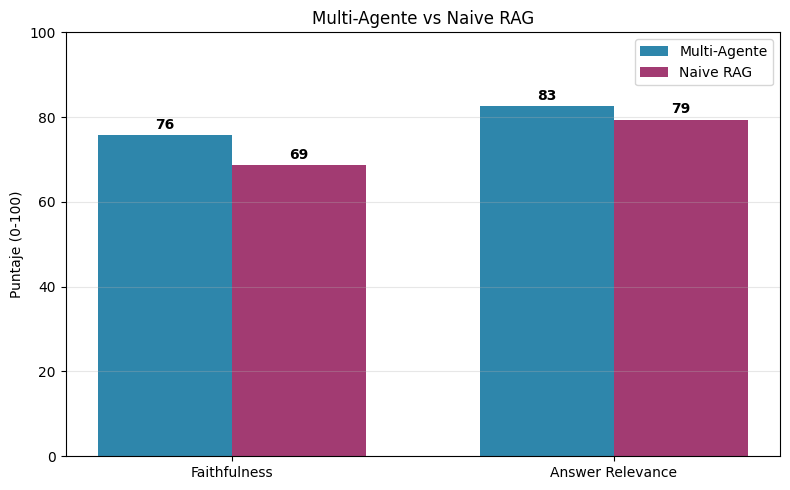

In [21]:
import matplotlib.pyplot as plt
import numpy as np

metricas = tabla_comparativa["Métrica"].str.replace(" (0-100)", "", regex=False)
x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - ancho/2, tabla_comparativa["Sistema Multi-Agente"], ancho, label="Multi-Agente", color="#2E86AB")
ax.bar(x + ancho/2, tabla_comparativa["Naive RAG"], ancho, label="Naive RAG", color="#A23B72")

ax.set_ylabel("Puntaje (0-100)")
ax.set_title("Multi-Agente vs Naive RAG")
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(tabla_comparativa["Sistema Multi-Agente"]):
    ax.text(i - ancho/2, v + 1.5, f"{v:.0f}", ha="center", fontweight="bold")
for i, v in enumerate(tabla_comparativa["Naive RAG"]):
    ax.text(i + ancho/2, v + 1.5, f"{v:.0f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("comparativa_metricas.png", dpi=150)
plt.show()


## 13. Diagrama del grafo de agentes

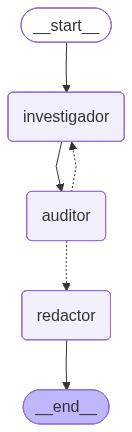

In [22]:
from IPython.display import Image, display

png_bytes = sistema_multiagente.get_graph().draw_mermaid_png()
with open("diagrama_grafo.png", "wb") as f:
    f.write(png_bytes)
display(Image(png_bytes))


## 14. Interfaz de demostración

Interfaz de chat sobre Gradio para exponer el funcionamiento del sistema de forma interactiva.

In [23]:
import gradio as gr

def chat_demo(pregunta, historial):
    estado = responder_multiagente(pregunta)
    debug_info = "\n".join(estado["historial_debug"])
    return f"{estado['respuesta_final']}\n\n---\n**Trazabilidad interna:**\n{debug_info}"

demo = gr.ChatInterface(
    fn=chat_demo,
    title="Sistema Multi-Agente de Auditoría Financiera",
    description="Investigador → Auditor de Hechos → Redactor.",
)

demo.launch(share=True, debug=False)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://b0595ffa4b5e522702.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
